In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import torch
import pandas as pd

from scipy.ndimage import gaussian_filter
from keras.models import Sequential
from keras.layers import Dense, Activation, LeakyReLU
from keras.optimizers import Adam
from torch.utils.data import Dataset
from keras import backend as K

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def create_histogram(
    x,
    y,
    resolution=64,
    value_range=(-1,1)
):
#crear imagen
    H, _, _ = np.histogram2d(
        x,
        y,
        bins=resolution,
        range=[
            [value_range[0], value_range[1]],
            [value_range[0], value_range[1]]
        ]
    )
#Normalización
    if H.max() > 0:
        H = H / H.max()
#Ajuste a [-1,1] para tanh de GAN
    H = H * 2 - 1

    return H

In [ ]:
class ClusterDataset(Dataset):
    def __init__(self, files, folder, q, resolution):
#Leemos CSV, extraemos puntos IQ, convertimos a histograma y creamos Dataset para GAN
        self.data = []

        for file in files:

            path = os.path.join(folder, file)
            df = pd.read_csv(path)

            for sample_id in df["Sample_Id"].unique():

                df_sample = df[df["Sample_Id"] == sample_id]
                cluster = df_sample[df_sample["Q"] == q]

                x = cluster["X_norm"].values
                y = cluster["Y_norm"].values

                if len(x) < 10: #per clusters que tenen pocs punts
                  continue

                H = create_histogram(
                    x,
                    y,
                    resolution
                )
                self.data.append(H)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(0)
        return img

In [ ]:
data_ref_path = "/content/drive/MyDrive/TFG/data_processed/reference_clusters"
data_alt_path = "/content/drive/MyDrive/TFG/data_processed/altered_clusters"
files_ref = sorted(os.listdir(data_ref_path))
files_alt = sorted(os.listdir(data_alt_path))

print("Número de archivos:", len(files_ref))

#for f in files_ref:
#    print(f)

print("Número de archivos:", len(files_alt))
#for f in files_alt:
 #   print(f)

q = 0                # cluster a analizar
resolution = 64

Número de archivos: 25
Número de archivos: 24


In [ ]:
dataset = ClusterDataset(files_ref, data_ref_path, q, resolution=resolution)
dataset_alt= ClusterDataset(files_alt, data_alt_path, q, resolution=resolution)

def load_data(dataset):
    data = []
    for i in range(len(dataset)):
        img = dataset[i][0].numpy()
        img = img.squeeze()
        data.append(img)
    return np.array(data)

X_train = load_data(dataset)
X_altered = load_data(dataset_alt)

print("Dataset shape:", X_train.shape)
print ("Dataset altered shape: ", X_altered.shape)

Dataset shape: (1250, 64, 64)
Dataset altered shape:  (7500, 64, 64)


In [ ]:
#imagenes 64x64 a vectores de resolution*resolution
def preprocess(x):
    x = x.reshape(-1, resolution*resolution)
    x = np.float64(x)
    return x

In [ ]:
X_train_real = preprocess(X_train)
X_train_altered = preprocess(X_altered)
print(X_train_real.shape)
print(X_train_altered.shape)

(1250, 4096)
(7500, 4096)


In [ ]:
def make_latent_samples(n_samples, sample_size):
    #return np.random.uniform(-1, 1, size=(n_samples, sample_size))
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

In [ ]:
def make_labels(size):
    return np.ones([size, 1]), np.zeros([size, 1])

In [ ]:
def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable

In [ ]:
def make_simple_GAN(sample_size,
                    g_hidden_size,
                    d_hidden_size,
                    leaky_alpha,
                    g_learning_rate,
                    d_learning_rate):
    K.clear_session()

    generator = Sequential([
        Dense(g_hidden_size, input_shape=(sample_size,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(resolution*resolution),
        Activation('tanh')
    ], name='generator')

    discriminator = Sequential([
        Dense(d_hidden_size, input_shape=(resolution*resolution,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(1),
        Activation('sigmoid')
    ], name='discriminator')

    gan = Sequential([
        generator,
        discriminator
    ])

    discriminator.compile(optimizer=Adam(learning_rate=d_learning_rate,beta_1=0.5), loss='binary_crossentropy')
    gan.compile(optimizer=Adam(learning_rate=g_learning_rate,beta_1=0.5), loss='binary_crossentropy')

    return gan, generator, discriminator

In [ ]:
#visualitzar valors (estem agafant nomes q = 0)
print("Shape X_train:", X_train.shape)
print("Min:", X_train.min())
print("Max:", X_train.max())

Shape X_train: (1250, 64, 64)
Min: -1.0
Max: 1.0


In [ ]:
# hyperparameters
sample_size     = 100     # latent sample size (i.e., 100 random numbers)
g_hidden_size   = 256
d_hidden_size   = 256
leaky_alpha     = 0.2
g_learning_rate = 0.0002  # learning rate for the generator
d_learning_rate = 0.0002   # learning rate for the discriminator
epochs          = 500
batch_size      = 64      # train batch size
eval_size       = 16      # evaluate size
smooth          = 0.1

# labels for the batch size and the test size
y_train_real, y_train_fake = make_labels(batch_size)
y_eval_real,  y_eval_fake  = make_labels(eval_size)

# create a GAN, a generator and a discriminator
gan, generator, discriminator = make_simple_GAN(
    sample_size,
    g_hidden_size,
    d_hidden_size,
    leaky_alpha,
    g_learning_rate,
    d_learning_rate)

losses = []
for e in range(epochs):
    for i in range(len(X_train_real)//batch_size):

        X_batch_real = X_train_real[i*batch_size:(i+1)*batch_size]

        # latent samples and the generated  images
        latent_samples = make_latent_samples(batch_size, sample_size)
        X_batch_fake = generator.predict_on_batch(latent_samples)

        # train the discriminator to detect real and fake images
        make_trainable(discriminator, True)
        discriminator.train_on_batch(X_batch_real, y_train_real * (1 - smooth))
        discriminator.train_on_batch(X_batch_fake, y_train_fake)

        # train the generator via GAN
        make_trainable(discriminator, False)
        gan.train_on_batch(latent_samples, y_train_real)

    # evaluate
    X_eval_real = X_train_real[np.random.choice(len(X_train_real), eval_size, replace=False)]
    latent_samples = make_latent_samples(eval_size, sample_size)
    X_eval_fake = generator.predict_on_batch(latent_samples)

    d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
    d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)
    g_loss  = gan.test_on_batch(latent_samples, y_eval_real) # we want the fake to be realistic!

    losses.append((d_loss, g_loss))

    print("Epoch: {:>3}/{} Discriminator Loss: {:>6.4f} Generator Loss: {:>6.4f}".format(
        e+1, epochs, d_loss, g_loss))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch:   1/500 Discriminator Loss: 2.2267 Generator Loss: 0.3606
Epoch:   2/500 Discriminator Loss: 1.8851 Generator Loss: 0.5303
Epoch:   3/500 Discriminator Loss: 1.6680 Generator Loss: 0.6277
Epoch:   4/500 Discriminator Loss: 1.5311 Generator Loss: 0.7347
Epoch:   5/500 Discriminator Loss: 1.4170 Generator Loss: 0.9338
Epoch:   6/500 Discriminator Loss: 1.3209 Generator Loss: 1.1345
Epoch:   7/500 Discriminator Loss: 1.2322 Generator Loss: 1.2829
Epoch:   8/500 Discriminator Loss: 1.1592 Generator Loss: 1.3829
Epoch:   9/500 Discriminator Loss: 1.1032 Generator Loss: 1.4441
Epoch:  10/500 Discriminator Loss: 1.0593 Generator Loss: 1.4868
Epoch:  11/500 Discriminator Loss: 1.0250 Generator Loss: 1.5153
Epoch:  12/500 Discriminator Loss: 0.9969 Generator Loss: 1.5378
Epoch:  13/500 Discriminator Loss: 0.9717 Generator Loss: 1.5558
Epoch:  14/500 Discriminator Loss: 0.9497 Generator Loss: 1.5679
Epoch:  15/500 Discriminator Loss: 0.9306 Generator Loss: 1.5771
Epoch:  16/500 Discrimina

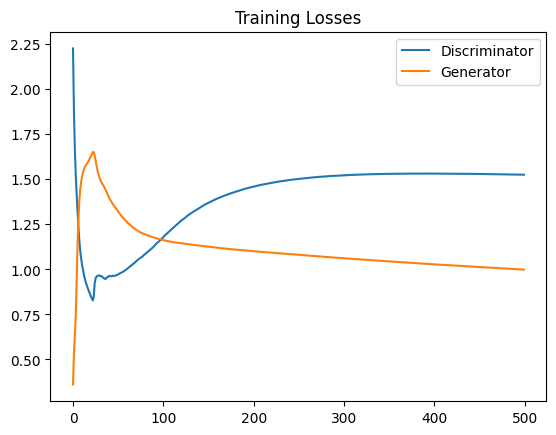

In [ ]:
losses = np.array(losses)

fig, ax = plt.subplots()
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()
plt.show()

In [ ]:
def deprocess(x):
    x = (x + 1) / 2.0 * 255.0
    x = np.clip(x, 0, 255)
    x = np.uint8(x)
    x = x.reshape(resolution, resolution)
    return x



In [ ]:
def get_scores(discriminator, X):
    return discriminator.predict(X).flatten()

In [ ]:
#EVALUACION
# ---- 1. Scores en datos normales ----
scores_real = get_scores(discriminator, X_train_real)

# ---- 2. Calcular threshold ----
threshold_perc = np.percentile(scores_real, 5)
mu = np.mean(scores_real)
sigma = np.std(scores_real)

threshold_stat = mu - 3 * sigma

print(f"Threshold (5th percentile): {threshold_perc:.4f}")
print(f"Threshold (stadistic): {threshold_stat:.4f}")



40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Threshold (5th percentile): 0.4215
Threshold (stadistic): 0.4178


In [ ]:
# ---- 3. Scores en datos alterados ----

X_altered = preprocess(X_altered)
scores_altered = get_scores(discriminator, X_altered)

# ---- 4. Detección ----
det_stat = np.mean(scores_altered < threshold_stat)
det_perc = np.mean(scores_altered < threshold_perc)

print(f"Detection rate: {det_stat:.4f}")
print(f"Detection rate (5th percentile): {det_perc:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Detection rate: 0.0019
Detection rate (5th percentile): 0.0396


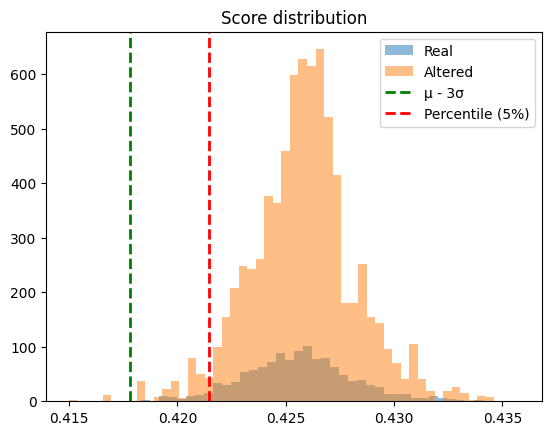

In [ ]:
import matplotlib.pyplot as plt

plt.hist(scores_real, bins=50, alpha=0.5, label='Real')
plt.hist(scores_altered, bins=50, alpha=0.5, label='Altered')
plt.axvline(threshold_stat, color='green', linestyle='--', linewidth=2, label='μ - 3σ')
plt.axvline(threshold_perc, color='red', linestyle='--', linewidth=2, label='Percentile (5%)')
plt.legend()
plt.title("Score distribution")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step


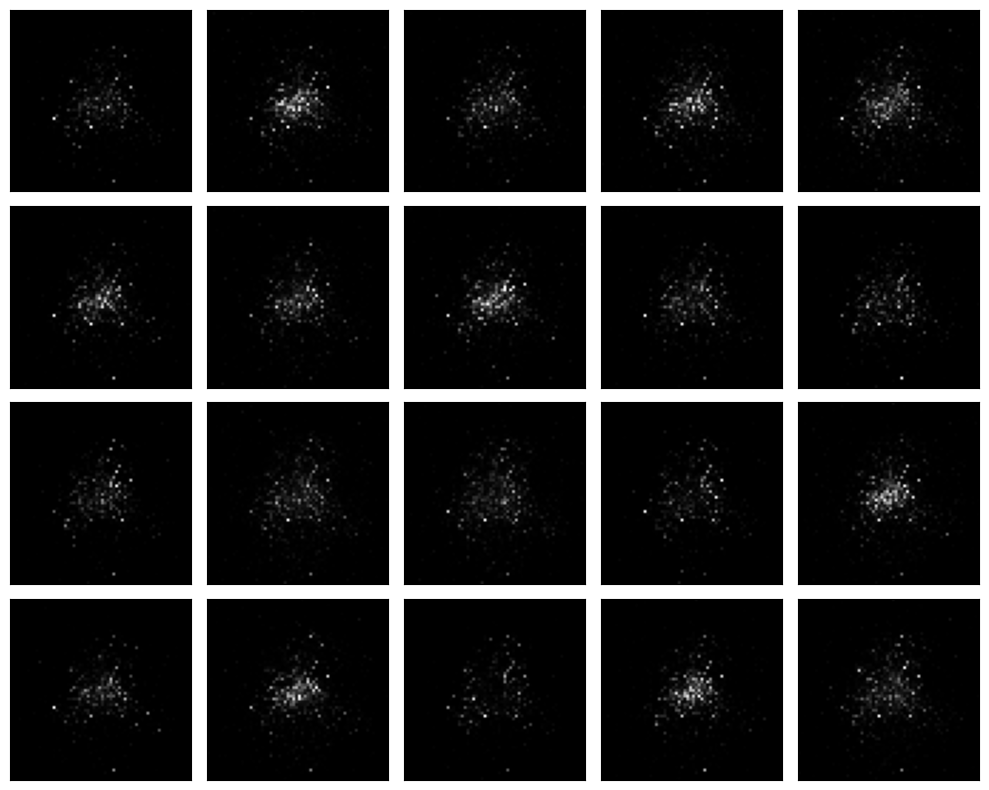

In [ ]:
#EJEMPLO DE IMAGENES GENERADAS POR EL GENERADOR
latent_samples = make_latent_samples(20, sample_size)
generated_digits = generator.predict(latent_samples)

plt.figure(figsize=(10, 8))

for i in range(20):

    img = deprocess(generated_digits[i])

    plt.subplot(4, 5, i+1)
    plt.imshow(img, cmap='gray')

    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [ ]:
def histogram_to_iq_points(
    hist,
    num_points=128,
    value_range=(-1, 1)
):

    # -----------------------------
    # Eliminar dimensión extra
    # -----------------------------
    if len(hist.shape) == 3:
        hist = hist.squeeze()

    # -----------------------------
    # Convertir [-1,1] → [0,1]
    # -----------------------------
    hist = (hist + 1) / 2

    # -----------------------------
    # Evitar negativos
    # -----------------------------
    hist = np.clip(hist, 0, None)

    # -----------------------------
    # Normalizar como probabilidad
    # -----------------------------
    prob = hist / np.sum(hist)

    resolution = hist.shape[0]

    # -----------------------------
    # Crear índices planos
    # -----------------------------
    flat_prob = prob.flatten()

    # -----------------------------
    # Sampling probabilístico
    # -----------------------------
    sampled_idx = np.random.choice(
        len(flat_prob),
        size=num_points,
        p=flat_prob
    )

    # -----------------------------
    # Convertir índices → coordenadas 2D
    # -----------------------------
    rows, cols = np.unravel_index(sampled_idx, (resolution, resolution))

    # -----------------------------
    # Convertir píxeles → coordenadas IQ
    # -----------------------------
    min_val, max_val = value_range

    x = min_val + (cols / resolution) * (max_val - min_val)
    y = min_val + (rows / resolution) * (max_val - min_val)

    # -----------------------------
    # Añadir jitter sub-píxel
    # -----------------------------
    pixel_size = (max_val - min_val) / resolution

    x += np.random.uniform(-pixel_size/2, pixel_size/2, size=num_points)
    y += np.random.uniform(-pixel_size/2, pixel_size/2, size=num_points)

    return x, y

In [ ]:
def iq_to_histogram(
    x,
    y,
    resolution=64,
    value_range=(-1,1)
):

    return create_histogram(
    x,
    y,
    resolution,
    value_range
)

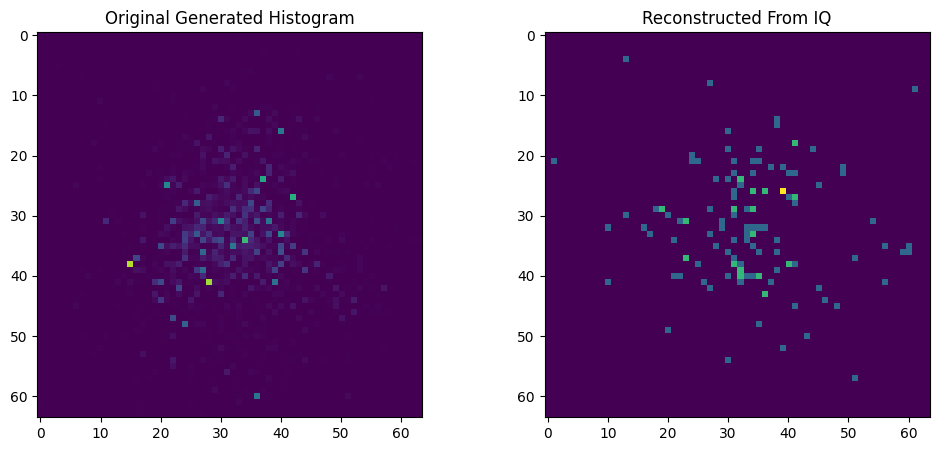

In [ ]:
#VISUALIZACION FLUJO SISTEMA
#primer sample de los generados lo pasamos a histograma de res*res
generated_hist = generated_digits[0]
generated_hist = generated_hist.reshape(
    resolution,
    resolution
)

# histograma → IQ (SALIDA GENERADOR)
x_fake, y_fake = histogram_to_iq_points(
    generated_hist,
    num_points=128
)

# IQ → histograma (ENTRADA DISCRIMINADOR)
reconstructed_hist = iq_to_histogram(
    x_fake,
    y_fake,
    resolution=resolution
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(
    generated_hist,
    cmap='viridis',
    vmin=-1,
    vmax=1
)
plt.title("Original Generated Histogram")

plt.subplot(1,2,2)
plt.imshow(
    reconstructed_hist,
    cmap='viridis',
    vmin=-1,
    vmax=1
)
plt.title("Reconstructed From IQ")

plt.show()

In [ ]:
# ----------------------------------
# IQ → histograma detector (ENTRADA DISCRIMINADOR)
# ----------------------------------

detector_hist = iq_to_histogram(
    x_fake,
    y_fake,
    resolution=resolution
)

detector_input = detector_hist.reshape(
    1,
    resolution * resolution
)

score = discriminator.predict(detector_input)

print("Detection score:", score[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
Detection score: 0.42662022


In [ ]:
class GeneratorAgent:

    def __init__(
        self,
        generator,
        sample_size,
        resolution
    ):

        self.generator = generator
        self.sample_size = sample_size
        self.resolution = resolution

    def generate(self,
                 num_points=128):

        latent = make_latent_samples(
            1,
            self.sample_size
        )
        #genera una predicción sintetica gracias al entreno previo
        generated_hist = self.generator.predict(latent)[0]
        # 64x64
        generated_hist = generated_hist.reshape(
            self.resolution,
            self.resolution
        )

        x_fake, y_fake = histogram_to_iq_points(
            generated_hist,
            num_points=num_points
        )

        return {
            "x": x_fake,
            "y": y_fake
        }

In [ ]:
class DetectorAgent:

    def __init__(
        self,
        discriminator,
        resolution
    ):

        self.discriminator = discriminator
        self.resolution = resolution

    def detect(
        self,
        x,
        y
    ):

        H = iq_to_histogram(
            x,
            y,
            resolution=self.resolution
        )

        H_input = H.reshape(
            1,
            self.resolution * self.resolution
        )

        score = self.discriminator.predict(H_input)

        return score[0][0]

In [ ]:
generator_agent = GeneratorAgent(
    generator,
    sample_size,
    resolution
)

detector_agent = DetectorAgent(
    discriminator,
    resolution
)

message = generator_agent.generate()

score = detector_agent.detect(
    message["x"],
    message["y"]
)

print("Distributed score:", score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Distributed score: 0.42782226


In [ ]:
n_samples = 100

correct = 0
wrong = 0

scores = []

for i in range(n_samples):

    # -------------------------
    # Generador distribuido
    # -------------------------
    message = generator_agent.generate()

    # -------------------------
    # Detector distribuido
    # -------------------------
    score = detector_agent.detect(
        message["x"],
        message["y"]
    )

    scores.append(score)

    # -------------------------
    # Evaluación
    # -------------------------
    if score < threshold_perc:

        # Detectó correctamente fake/anomalía
        correct += 1

    else:

        # Pensó que era legítimo
        wrong += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

In [ ]:
accuracy = correct / n_samples

print("Correct detections:", correct)
print("Wrong detections:", wrong)
print("Detection accuracy:", accuracy)

Correct detections: 7
Wrong detections: 93
Detection accuracy: 0.07


# Multi-cluster GAN detector (q = 0..15)

Esta sección reemplaza la evaluación anterior por una metodología válida para detección de anomalías:

- Entrenamiento por cluster `q` usando solo `reference`.
- Split por `Sample_Id` en train/validation para evitar fuga de datos.
- Umbral calculado en `reference` de validación.
- Evaluación en `altered` (anómalos) con métricas: `TPR`, `FPR`, `ROC-AUC`.
- Resumen adicional para clusters con tampering+evasion: `q in {0,6,9,14}`.

Recomendación práctica:

- Primera fase (más robusta): **modelo independiente por cluster**.
- Segunda fase (si quieres escalar): modelo conjunto condicionado por `q` (cGAN), comparando contra esta baseline.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Activation, LeakyReLU
from keras.optimizers import Adam
from keras import backend as K

from sklearn.metrics import roc_auc_score

# -----------------------------
# Config
# -----------------------------
DATA_REF_PATH = "/content/drive/MyDrive/TFG/data_processed/reference_clusters"
DATA_ALT_PATH = "/content/drive/MyDrive/TFG/data_processed/altered_clusters"

RESOLUTION = 64
CLUSTERS = list(range(16))
MIXED_ATTACK_CLUSTERS = {0, 6, 9, 14}  # tampering + evasion

SAMPLE_SIZE = 100
G_HIDDEN_SIZE = 256
D_HIDDEN_SIZE = 256
LEAKY_ALPHA = 0.2
G_LR = 0.0002
D_LR = 0.0002
EPOCHS = 250
BATCH_SIZE = 64
SMOOTH = 0.1

VAL_FRAC = 0.2
THRESHOLD_PERCENTILE = 5
MIN_POINTS_PER_CLUSTER_SAMPLE = 10
SEED = 42

rng = np.random.default_rng(SEED)


def create_histogram(x, y, resolution=64, value_range=(-1, 1)):
    H, _, _ = np.histogram2d(
        x,
        y,
        bins=resolution,
        range=[[value_range[0], value_range[1]], [value_range[0], value_range[1]]]
    )
    if H.max() > 0:
        H = H / H.max()
    H = H * 2 - 1
    return H


def preprocess(x, resolution=64):
    return x.reshape(-1, resolution * resolution).astype(np.float64)


def make_latent_samples(n_samples, sample_size):
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))


def make_simple_gan(sample_size, g_hidden_size, d_hidden_size, leaky_alpha, g_lr, d_lr, resolution):
    K.clear_session()

    generator = Sequential([
        Dense(g_hidden_size, input_shape=(sample_size,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(resolution * resolution),
        Activation("tanh")
    ], name="generator")

    discriminator = Sequential([
        Dense(d_hidden_size, input_shape=(resolution * resolution,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(1),
        Activation("sigmoid")
    ], name="discriminator")

    gan = Sequential([generator, discriminator], name="gan")

    discriminator.compile(
        optimizer=Adam(learning_rate=d_lr, beta_1=0.5),
        loss="binary_crossentropy"
    )
    gan.compile(
        optimizer=Adam(learning_rate=g_lr, beta_1=0.5),
        loss="binary_crossentropy"
    )

    return gan, generator, discriminator


def make_trainable(model, trainable):
    for layer in model.layers:
        layer.trainable = trainable


def load_cluster_histograms(files, folder, q, resolution=64, min_points=10):
    histograms = []
    sample_keys = []

    for file_name in files:
        path = os.path.join(folder, file_name)
        df = pd.read_csv(path)

        for sample_id in df["Sample_Id"].unique():
            sample_df = df[df["Sample_Id"] == sample_id]
            cluster_df = sample_df[sample_df["Q"] == q]

            x = cluster_df["X_norm"].values
            y = cluster_df["Y_norm"].values

            if len(x) < min_points:
                continue

            H = create_histogram(x, y, resolution=resolution)
            histograms.append(H)
            sample_keys.append(f"{file_name}::{sample_id}")

    if len(histograms) == 0:
        return np.empty((0, resolution, resolution), dtype=np.float64), np.array([])

    return np.array(histograms, dtype=np.float64), np.array(sample_keys)


def split_reference_by_sample_id(sample_keys, val_frac=0.2, seed=42):
    unique_keys = np.unique(sample_keys)
    rng_local = np.random.default_rng(seed)
    rng_local.shuffle(unique_keys)

    n_val = max(1, int(len(unique_keys) * val_frac))
    val_keys = set(unique_keys[:n_val])

    is_val = np.array([k in val_keys for k in sample_keys])
    is_train = ~is_val

    return is_train, is_val


def train_gan_for_cluster(X_train_real, resolution=64):
    gan, generator, discriminator = make_simple_gan(
        sample_size=SAMPLE_SIZE,
        g_hidden_size=G_HIDDEN_SIZE,
        d_hidden_size=D_HIDDEN_SIZE,
        leaky_alpha=LEAKY_ALPHA,
        g_lr=G_LR,
        d_lr=D_LR,
        resolution=resolution
    )

    n_train = len(X_train_real)
    if n_train < 2:
        return gan, generator, discriminator

    for epoch in range(EPOCHS):
        indices = np.arange(n_train)
        np.random.shuffle(indices)

        for start in range(0, n_train, BATCH_SIZE):
            batch_idx = indices[start:start + BATCH_SIZE]
            real_batch = X_train_real[batch_idx]
            current_bs = len(real_batch)
            if current_bs == 0:
                continue

            y_real = np.ones((current_bs, 1)) * (1 - SMOOTH)
            y_fake = np.zeros((current_bs, 1))

            latent_samples = make_latent_samples(current_bs, SAMPLE_SIZE)
            fake_batch = generator.predict_on_batch(latent_samples)

            make_trainable(discriminator, True)
            discriminator.train_on_batch(real_batch, y_real)
            discriminator.train_on_batch(fake_batch, y_fake)

            make_trainable(discriminator, False)
            gan.train_on_batch(latent_samples, np.ones((current_bs, 1)))

        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"  Epoch {epoch + 1}/{EPOCHS} done")

    return gan, generator, discriminator


def evaluate_cluster(discriminator, X_ref_val, X_alt, threshold_percentile=5):
    scores_ref = discriminator.predict(X_ref_val, verbose=0).flatten()
    scores_alt = discriminator.predict(X_alt, verbose=0).flatten()

    threshold = np.percentile(scores_ref, threshold_percentile)

    pred_ref_anomaly = scores_ref < threshold
    pred_alt_anomaly = scores_alt < threshold

    fpr = float(np.mean(pred_ref_anomaly))
    tpr = float(np.mean(pred_alt_anomaly))

    y_true = np.concatenate([np.zeros_like(scores_ref), np.ones_like(scores_alt)])
    anomaly_score = np.concatenate([-scores_ref, -scores_alt])

    try:
        auc = float(roc_auc_score(y_true, anomaly_score))
    except ValueError:
        auc = np.nan

    return {
        "threshold": float(threshold),
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc,
        "scores_ref": scores_ref,
        "scores_alt": scores_alt
    }


files_ref = sorted(os.listdir(DATA_REF_PATH))
files_alt = sorted(os.listdir(DATA_ALT_PATH))

print("Reference files:", len(files_ref))
print("Altered files:", len(files_alt))

results = []

for q in CLUSTERS:
    print("\n" + "=" * 60)
    print(f"Cluster q={q}")

    X_ref, ref_keys = load_cluster_histograms(
        files=files_ref,
        folder=DATA_REF_PATH,
        q=q,
        resolution=RESOLUTION,
        min_points=MIN_POINTS_PER_CLUSTER_SAMPLE
    )

    X_alt, _ = load_cluster_histograms(
        files=files_alt,
        folder=DATA_ALT_PATH,
        q=q,
        resolution=RESOLUTION,
        min_points=MIN_POINTS_PER_CLUSTER_SAMPLE
    )

    if len(X_ref) < 20 or len(X_alt) < 5:
        print(f"  Skip q={q}: insufficient data (ref={len(X_ref)}, alt={len(X_alt)})")
        results.append({
            "q": q,
            "attack_profile": "tampering+evasion" if q in MIXED_ATTACK_CLUSTERS else "tampering",
            "n_ref": int(len(X_ref)),
            "n_alt": int(len(X_alt)),
            "n_train_ref": 0,
            "n_val_ref": 0,
            "threshold": np.nan,
            "fpr": np.nan,
            "tpr": np.nan,
            "auc": np.nan
        })
        continue

    train_mask, val_mask = split_reference_by_sample_id(ref_keys, val_frac=VAL_FRAC, seed=SEED)

    X_ref_train = preprocess(X_ref[train_mask], resolution=RESOLUTION)
    X_ref_val = preprocess(X_ref[val_mask], resolution=RESOLUTION)
    X_alt_eval = preprocess(X_alt, resolution=RESOLUTION)

    print(f"  ref train={len(X_ref_train)} | ref val={len(X_ref_val)} | alt={len(X_alt_eval)}")

    _, generator, discriminator = train_gan_for_cluster(X_ref_train, resolution=RESOLUTION)

    metrics = evaluate_cluster(
        discriminator=discriminator,
        X_ref_val=X_ref_val,
        X_alt=X_alt_eval,
        threshold_percentile=THRESHOLD_PERCENTILE
    )

    print(
        f"  threshold={metrics['threshold']:.4f} | "
        f"TPR={metrics['tpr']:.4f} | FPR={metrics['fpr']:.4f} | AUC={metrics['auc']:.4f}"
    )

    results.append({
        "q": q,
        "attack_profile": "tampering+evasion" if q in MIXED_ATTACK_CLUSTERS else "tampering",
        "n_ref": int(len(X_ref)),
        "n_alt": int(len(X_alt)),
        "n_train_ref": int(len(X_ref_train)),
        "n_val_ref": int(len(X_ref_val)),
        "threshold": metrics["threshold"],
        "fpr": metrics["fpr"],
        "tpr": metrics["tpr"],
        "auc": metrics["auc"]
    })

results_df = pd.DataFrame(results).sort_values("q").reset_index(drop=True)

print("\nPer-cluster results:")
display(results_df)

valid_df = results_df.dropna(subset=["tpr", "fpr", "auc"])

if len(valid_df) > 0:
    print("\nGlobal mean metrics (valid clusters):")
    print(valid_df[["tpr", "fpr", "auc"]].mean())

    print("\nWeighted TPR/FPR by n_alt:")
    weighted_tpr = np.average(valid_df["tpr"], weights=valid_df["n_alt"])
    weighted_fpr = np.average(valid_df["fpr"], weights=valid_df["n_alt"])
    print({"weighted_tpr": float(weighted_tpr), "weighted_fpr": float(weighted_fpr)})

    print("\nMetrics by attack profile:")
    display(valid_df.groupby("attack_profile")[["tpr", "fpr", "auc"]].mean())

# Optional: quick visualization
if len(valid_df) > 0:
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.bar(valid_df["q"].astype(str), valid_df["tpr"])
    plt.title("TPR by cluster")
    plt.xlabel("q")

    plt.subplot(1, 3, 2)
    plt.bar(valid_df["q"].astype(str), valid_df["fpr"])
    plt.title("FPR by cluster")
    plt.xlabel("q")

    plt.subplot(1, 3, 3)
    plt.bar(valid_df["q"].astype(str), valid_df["auc"])
    plt.title("AUC by cluster")
    plt.xlabel("q")

    plt.tight_layout()
    plt.show()